<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/power/process_coupled_offshore_electrification_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Process-coupled offshore electrification study with NeqSim

This notebook starts with the real NeqSim separation and recompression process in
[`comparesimulations.ipynb`](../process/comparesimulations.ipynb), adds a
70-to-160 bara export-compression stage and export cooling, and scales the feed to
an offshore-hub flow rate. The resulting compressor and cooling duties—not an
assumed flat process load—drive a chronological power study.

Six operating concepts are compared: gas turbines only, partial and full shore
power, offshore wind with gas balancing, wind with a battery, and a combined
shore-wind-battery case. Gas-turbine fuel and CO₂ are calculated with NeqSim's
native catalogue model at the actual hourly load.

This is a transparent screening study, not a design basis, power-system stability
assessment, vendor guarantee, or forecast for a named field.

## What makes the energy calculation process-coupled?

The calculation chain is explicit:

1. NeqSim solves phase separation, recompression, aftercooling, export compression,
   and export cooling at several gas flow rates.
2. The shaft power of each `Compressor` and the thermal duty of each `Cooler` are
   read from those solved units.
3. A NeqSim `GasTurbineUnit` is connected directly to both compressors with
   `addPowerConsumer`, and all three units share an electrical `EnergyBus`.
4. A checked interpolation of the NeqSim duty curve converts the hourly production
   profile into electrical demand.
5. `EnergyTimeSeriesSimulator` allocates wind, shore power, and gas generation.
   Stateful battery cases use NeqSim `BatteryStorage`.
6. Every hourly gas-generation point is converted to fuel use and direct CO₂ with
   NeqSim's native part-load turbine performance map.

The process-side electrical demand is

$$
P_{process}(t) =
P_{recomp}(t) + P_{export}(t)
+ \frac{Q_{cold}(t)}{COP}
+ f_{cool}\left(Q_{after}(t)+Q_{export,cool}(t)\right)
$$

where $COP$ and $f_{cool}$ are editable utility assumptions. Compressor powers and
cooler duties are direct NeqSim results.

## Learning objectives and decision questions

After running the notebook, you can:

- trace each megawatt from a named NeqSim process unit into the electrical balance;
- see how gas flow and export pressure affect process power and CO₂;
- compare direct offshore emissions with location-based imported-power emissions;
- quantify gas-turbine part-load penalties when wind or shore power reduces demand;
- test whether a battery displaces gas generation or mainly reduces curtailment;
- check N+1 gas-turbine capacity even when annual gas generation is low; and
- edit the flow, pressure, cable, wind, battery, and economic assumptions.

The central question is not simply “how much renewable energy is available?” It is
“how does a chronological supply option serve a process load that changes with
production, while retaining enough gas-turbine capacity to balance and back up the
offshore system?”

## Public anchors and transparent study assumptions

[Hywind Tampen](https://www.equinor.com/energy/hywind-tampen) has 94.6 MW
installed capacity and is reported to cover about 35% of annual power demand for
five Snorre and Gullfaks platforms. Only the public capacity is used here; the wind
series is synthetic.

The [Norwegian Offshore Directorate](https://www.sodir.no/en/whats-new/publications/reports/the-shelf/the-shelf-in-2025/production-operating-fields-and-investments/)
identifies gas-turbine combustion as the main source of offshore emissions and
power from shore as the most important measure behind the reduction since 2015.

[NVE](https://www.nve.no/nytt-fra-nve/nyheter-energi/klimagassutslipp-knyttet-til-norsk-stroemforbruk-gaar-ned/)
reports 11.9 g CO₂e/kWh for average physical Norwegian electricity use in 2024.
Numerically, this is 11.9 kg CO₂e/MWh. It is used only for a location-based
screening metric; direct offshore emissions from imported electricity remain zero.

Flow rate, pressures, non-modelled utility loads, cable limits, outage chronology,
wind capacity factor, prices, and battery size are editable study assumptions.

## 1. Build a pinned revision of the NeqSim repository

This Colab setup fetches and compiles an exact commit from the
[`equinor/neqsim`](https://github.com/equinor/neqsim) repository. It starts JPype
with the freshly compiled classes before the shaded dependency JAR. No packaged
NeqSim binary replaces the repository build.

The first run can take several minutes because Maven dependencies must be
downloaded. Java 17 or newer is recommended.

In [1]:
import platform
import shutil
import subprocess
import sys
from pathlib import Path

NEQSIM_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_COMMIT = "77f4b5b1d225372947a69864b47940fe0f86430a"
NEQSIM_ROOT = Path("/tmp") / f"neqsim-source-{NEQSIM_COMMIT[:12]}"

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "jpype1==1.7.1",
    ]
)

if not (NEQSIM_ROOT / ".git").exists():
    shutil.rmtree(NEQSIM_ROOT, ignore_errors=True)
    subprocess.check_call(
        [
            "git",
            "init",
            "--quiet",
            "--initial-branch",
            "colab-build",
            str(NEQSIM_ROOT),
        ]
    )
    subprocess.check_call(
        [
            "git",
            "-C",
            str(NEQSIM_ROOT),
            "remote",
            "add",
            "origin",
            NEQSIM_REPOSITORY,
        ]
    )
    subprocess.check_call(
        [
            "git",
            "-C",
            str(NEQSIM_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_COMMIT,
        ]
    )
    subprocess.check_call(
        [
            "git",
            "-C",
            str(NEQSIM_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ]
    )

resolved_commit = subprocess.check_output(
    ["git", "-C", str(NEQSIM_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()
assert resolved_commit == NEQSIM_COMMIT

target_classes = NEQSIM_ROOT / "target" / "classes"
if not target_classes.exists():
    build_command = [
        str(NEQSIM_ROOT / "mvnw"),
        "--quiet",
        "-Dmaven.test.skip=true",
        "-Dmaven.wagon.http.retryHandler.count=5",
        "package",
    ]
    build_log = NEQSIM_ROOT / "colab-maven-build.log"
    for attempt in range(1, 4):
        completed = subprocess.run(
            build_command,
            cwd=NEQSIM_ROOT,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
        )
        build_log.write_text(completed.stdout, encoding="utf-8")
        if completed.returncode == 0:
            break
        if attempt == 3:
            print("\n".join(completed.stdout.splitlines()[-120:]))
            completed.check_returncode()

import jpype

jar_candidates = [
    path
    for path in (NEQSIM_ROOT / "target").glob("neqsim-*.jar")
    if not path.name.startswith("original-")
    and "-sources" not in path.name
    and "-javadoc" not in path.name
]
assert jar_candidates, "The NeqSim shaded JAR was not built."
neqsim_jar = max(jar_candidates, key=lambda path: path.stat().st_size)

if not jpype.isJVMStarted():
    jpype.startJVM(
        classpath=[
            str(target_classes),
            str(NEQSIM_ROOT / "src" / "main" / "resources"),
            str(neqsim_jar),
        ]
    )

JClass = jpype.JClass
java_system = JClass("java.lang.System")
print(f"NeqSim repository commit: {resolved_commit}")
print(f"NeqSim JAR: {neqsim_jar.name}")
print(f"Python: {platform.python_version()}")
print(f"Java: {java_system.getProperty('java.version')}")

NeqSim repository commit: 77f4b5b1d225372947a69864b47940fe0f86430a
NeqSim JAR: neqsim-3.16.0.jar
Python: 3.12.13
Java: 17.0.19


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from jpype import JArray, JDouble, JProxy

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThrottlingValve = JClass(
    "neqsim.process.equipment.valve.ThrottlingValve"
)
Cooler = JClass("neqsim.process.equipment.heatexchanger.Cooler")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass(
    "neqsim.process.equipment.compressor.Compressor"
)
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
GasTurbineCatalog = JClass(
    "neqsim.process.equipment.powergeneration.gasturbine."
    "GasTurbineCatalog"
)
GasTurbineUnit = JClass(
    "neqsim.process.equipment.powergeneration.gasturbine."
    "GasTurbineUnit"
)
EnergyBus = JClass("neqsim.process.equipment.stream.EnergyBus")
EnergyType = JClass("neqsim.process.equipment.stream.EnergyType")
EnergyPort = JClass("neqsim.process.equipment.stream.EnergyPort")
EnergyPortDirection = JClass(
    "neqsim.process.equipment.stream.EnergyPortDirection"
)
EnergyPortMode = JClass(
    "neqsim.process.equipment.stream.EnergyPortMode"
)
EnergyTimeSeriesProfile = JClass(
    "neqsim.process.equipment.energy.EnergyTimeSeriesProfile"
)
EnergyTimeSeriesSimulator = JClass(
    "neqsim.process.equipment.energy.EnergyTimeSeriesSimulator"
)
ProfileTarget = JClass(
    "neqsim.process.equipment.energy."
    "EnergyTimeSeriesSimulator$ProfileTarget"
)
BatteryStorage = JClass(
    "neqsim.process.equipment.battery.BatteryStorage"
)

plt.style.use("seaborn-v0_8-whitegrid")
COLOR_GAS = "#D55E00"
COLOR_WIND = "#56B4E9"
COLOR_SHORE = "#0072B2"
COLOR_BATTERY = "#009E73"
COLOR_PROCESS = "#3A3A3A"

In [3]:
public_and_study_inputs = pd.DataFrame(
    [
        {
            "Parameter": "Hywind Tampen installed capacity",
            "Value": 94.6,
            "Unit": "MW",
            "Type": "Public project fact",
        },
        {
            "Parameter": "Norwegian electricity factor, 2024",
            "Value": 11.9,
            "Unit": "kg CO₂e/MWh",
            "Type": "Public location-based factor",
        },
        {
            "Parameter": "Base rich-gas feed",
            "Value": 60.0,
            "Unit": "kg/s",
            "Type": "Editable study assumption",
        },
        {
            "Parameter": "Export pressure",
            "Value": 160.0,
            "Unit": "bara",
            "Type": "Editable study assumption",
        },
        {
            "Parameter": "Partial / full shore limits",
            "Value": "25 / 60",
            "Unit": "MW",
            "Type": "Editable study assumption",
        },
        {
            "Parameter": "Battery energy / power",
            "Value": "100 / 40",
            "Unit": "MWh / MW",
            "Type": "Editable study assumption",
        },
    ]
)
display(public_and_study_inputs)

,Parameter,Value,Unit,Type
0,Hywind Tampen installed capacity,94.6,MW,Public project fact
1,"Norwegian electricity factor, 2024",11.9,kg CO₂e/MWh,Public location-based factor
2,Base rich-gas feed,60.0,kg/s,Editable study assumption
3,Export pressure,160.0,bara,Editable study assumption
4,Partial / full shore limits,25 / 60,MW,Editable study assumption
5,Battery energy / power,100 / 40,MWh / MW,Editable study assumption


## 2. Build the real process and add export compression

The inlet composition and first separation/recompression train reproduce the model
structure in `comparesimulations.ipynb`. The additions are:

- an aftercooler from the 70 bara recompression discharge to 35 °C;
- an export compressor from 70 to 160 bara; and
- an export cooler to 35 °C.

The base flow is increased from 10 to 60 kg/s so equipment duties are representative
of a larger offshore processing hub. This is a scale assumption, not a claim about
a particular installation.

The steady-state mass check is

$$
\varepsilon_m =
\dot m_{feed} - \dot m_{export\ gas} - \dot m_{liquid}
$$

and must close within numerical precision.

In [4]:
COMPONENTS = {
    "nitrogen": 0.020,
    "CO2": 0.015,
    "methane": 0.800,
    "ethane": 0.080,
    "propane": 0.040,
    "i-butane": 0.015,
    "n-butane": 0.015,
    "i-pentane": 0.005,
    "n-pentane": 0.005,
    "n-hexane": 0.005,
}

BASE_FLOW_KG_S = 60.0
FEED_TEMPERATURE_C = 35.0
FEED_PRESSURE_BARA = 70.0
SEPARATION_PRESSURE_BARA = 30.0
SEPARATION_TEMPERATURE_C = 5.0
RECOMPRESSION_PRESSURE_BARA = 70.0
EXPORT_PRESSURE_BARA = 160.0
AFTERCOOLER_TEMPERATURE_C = 35.0
COMPRESSOR_EFFICIENCY = 0.78
TURBINE_MODEL = "LM2500PLUS_G4"
AMBIENT_TEMPERATURE_K = 281.15

process_inputs = pd.DataFrame(
    [
        ["Feed flow", BASE_FLOW_KG_S, "kg/s"],
        ["Feed pressure", FEED_PRESSURE_BARA, "bara"],
        ["Separator pressure", SEPARATION_PRESSURE_BARA, "bara"],
        ["Separator temperature", SEPARATION_TEMPERATURE_C, "°C"],
        ["Recompression pressure", RECOMPRESSION_PRESSURE_BARA, "bara"],
        ["Export pressure", EXPORT_PRESSURE_BARA, "bara"],
        ["Compressor isentropic efficiency", COMPRESSOR_EFFICIENCY, "-"],
    ],
    columns=["Input", "Value", "Unit"],
)
display(process_inputs)

,Input,Value,Unit
0,Feed flow,60.00,kg/s
1,Feed pressure,70.00,bara
2,Separator pressure,30.00,bara
3,Separator temperature,5.00,°C
4,Recompression pressure,70.00,bara
5,Export pressure,160.00,bara
6,Compressor isentropic efficiency,0.78,-


In [5]:
def build_fluid(flow_kg_s):
    fluid = SystemSrkEos(
        FEED_TEMPERATURE_C + 273.15,
        FEED_PRESSURE_BARA,
    )
    for component, fraction in COMPONENTS.items():
        fluid.addComponent(component, fraction)
    fluid.createDatabase(True)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(float(flow_kg_s), "kg/sec")
    return fluid


def build_process_case(flow_kg_s, connect_turbine=True):
    feed = Stream("rich gas feed", build_fluid(flow_kg_s))

    inlet_valve = ThrottlingValve("inlet pressure control", feed)
    inlet_valve.setOutletPressure(SEPARATION_PRESSURE_BARA)

    cold_separator_cooler = Cooler(
        "cold separator cooler",
        inlet_valve.getOutletStream(),
    )
    cold_separator_cooler.setOutTemperature(
        SEPARATION_TEMPERATURE_C + 273.15
    )

    separator = Separator(
        "cold separator",
        cold_separator_cooler.getOutletStream(),
    )

    recompressor = Compressor(
        "recompression compressor",
        separator.getGasOutStream(),
    )
    recompressor.setOutletPressure(RECOMPRESSION_PRESSURE_BARA)
    recompressor.setIsentropicEfficiency(COMPRESSOR_EFFICIENCY)

    recompression_aftercooler = Cooler(
        "recompression aftercooler",
        recompressor.getOutletStream(),
    )
    recompression_aftercooler.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )

    export_compressor = Compressor(
        "export compressor",
        recompression_aftercooler.getOutletStream(),
    )
    export_compressor.setOutletPressure(EXPORT_PRESSURE_BARA)
    export_compressor.setIsentropicEfficiency(
        COMPRESSOR_EFFICIENCY
    )

    export_cooler = Cooler(
        "export cooler",
        export_compressor.getOutletStream(),
    )
    export_cooler.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )

    process = ProcessSystem("process-coupled electrification case")
    equipment = [
        feed,
        inlet_valve,
        cold_separator_cooler,
        separator,
        recompressor,
        recompression_aftercooler,
        export_compressor,
        export_cooler,
    ]
    for unit in equipment:
        process.add(unit)

    turbine = None
    electrical_bus = None
    if connect_turbine:
        turbine_spec = GasTurbineCatalog.get(TURBINE_MODEL)
        turbine = GasTurbineUnit(
            "process gas turbine",
            export_cooler.getOutletStream(),
            turbine_spec,
        )
        turbine.setAmbientTemperatureK(AMBIENT_TEMPERATURE_K)
        turbine.setAmbientPressureBara(1.01325)
        turbine.addPowerConsumer(recompressor)
        turbine.addPowerConsumer(export_compressor)

        electrical_bus = EnergyBus(
            "compressor shaft-power bus",
            EnergyType.SHAFT_WORK,
        )
        recompressor.connectEnergyStream(
            "shaftPower",
            electrical_bus,
            EnergyPortMode.CALCULATED,
        )
        export_compressor.connectEnergyStream(
            "shaftPower",
            electrical_bus,
            EnergyPortMode.CALCULATED,
        )
        turbine.connectEnergyStream(
            "shaftPower",
            electrical_bus,
            EnergyPortMode.CALCULATED,
        )
        process.add(turbine)

    process.run()
    bus_report = (
        None
        if electrical_bus is None
        else electrical_bus.solveBalance()
    )
    return {
        "process": process,
        "feed": feed,
        "separator": separator,
        "cold cooler": cold_separator_cooler,
        "recompressor": recompressor,
        "recompression cooler": recompression_aftercooler,
        "export compressor": export_compressor,
        "export cooler": export_cooler,
        "turbine": turbine,
        "bus": electrical_bus,
        "bus report": bus_report,
    }

In [6]:
def process_results(case):
    feed = case["feed"]
    separator = case["separator"]
    recompressor = case["recompressor"]
    export_compressor = case["export compressor"]
    export_cooler = case["export cooler"]
    turbine = case["turbine"]

    feed_kg_h = feed.getFlowRate("kg/hr")
    gas_kg_h = export_cooler.getOutletStream().getFlowRate("kg/hr")
    liquid_kg_h = separator.getLiquidOutStream().getFlowRate("kg/hr")
    return {
        "Feed [kg/h]": feed_kg_h,
        "Export gas [kg/h]": gas_kg_h,
        "Liquid [kg/h]": liquid_kg_h,
        "Mass residual [kg/h]": feed_kg_h - gas_kg_h - liquid_kg_h,
        "Recompression [MW]": recompressor.getPower() / 1.0e6,
        "Export compression [MW]": (
            export_compressor.getPower() / 1.0e6
        ),
        "Cold duty [MWth]": abs(
            case["cold cooler"].getDuty()
        )
        / 1.0e6,
        "Recompression cooling [MWth]": abs(
            case["recompression cooler"].getDuty()
        )
        / 1.0e6,
        "Export cooling [MWth]": abs(
            case["export cooler"].getDuty()
        )
        / 1.0e6,
        "Export pressure [bara]": (
            export_cooler.getOutletStream().getPressure("bara")
        ),
        "Export temperature [°C]": (
            export_cooler.getOutletStream().getTemperature("C")
        ),
        "GT direct demand [MW]": (
            0.0
            if turbine is None
            else turbine.getDemandedPowerW() / 1.0e6
        ),
        "GT direct CO₂ [kg/h]": (
            0.0
            if turbine is None
            else turbine.getCO2EmissionKgPerHr()
        ),
        "GT load fraction [-]": (
            0.0
            if turbine is None
            else turbine.getLoadFraction()
        ),
        "Bus unmet [W]": (
            0.0
            if case["bus report"] is None
            else case["bus report"].getUnmetDemand()
        ),
    }


base_case = build_process_case(BASE_FLOW_KG_S)
base_result = process_results(base_case)
base_table = pd.DataFrame(
    {
        "Value": base_result,
    }
)
display(base_table.round(4))

,Value
Feed [kg/h],216000.0000
Export gas [kg/h],202941.8147
Liquid [kg/h],13058.1853
Mass residual [kg/h],0.0000
Recompression [MW],6.8756
Export compression [MW],7.2096
Cold duty [MWth],2.0460
Recompression cooling [MWth],5.8145
Export cooling [MWth],12.4598
Export pressure [bara],160.0000


The displayed gas-turbine demand is not entered manually. During the same process
run, `GasTurbineUnit` sums `getPower()` from the recompression and export
compressors. The shaft-work bus then checks that the turbine output equals those
two compressor inputs.

Cooler duties remain thermal quantities. The next section converts only the 5 °C
cold duty through an illustrative refrigeration coefficient of performance and
assigns a small auxiliary fraction to the seawater/air aftercoolers. This keeps the
boundary explicit.

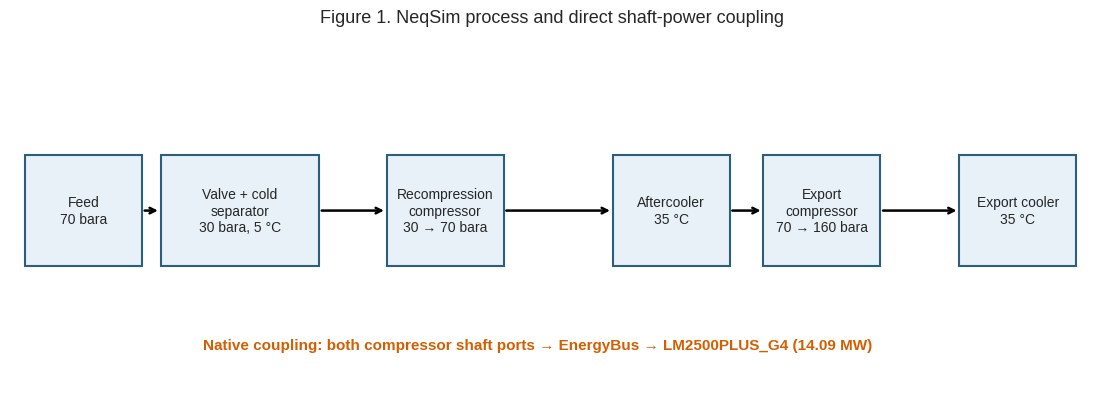

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.set_xlim(0, 14.4)
ax.set_ylim(0, 4)
ax.axis("off")

blocks = [
    (0.2, "Feed\n70 bara"),
    (2.0, "Valve + cold\nseparator\n30 bara, 5 °C"),
    (5.0, "Recompression\ncompressor\n30 → 70 bara"),
    (8.0, "Aftercooler\n35 °C"),
    (10.0, "Export\ncompressor\n70 → 160 bara"),
    (12.6, "Export cooler\n35 °C"),
]
for x_position, label in blocks:
    width = 1.55 if x_position != 2.0 else 2.1
    rectangle = plt.Rectangle(
        (x_position, 1.45),
        width,
        1.2,
        facecolor="#E8F1F8",
        edgecolor="#2C5F7C",
        linewidth=1.5,
    )
    ax.add_patch(rectangle)
    ax.text(
        x_position + width / 2.0,
        2.05,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )
for start, end in [
    (1.75, 2.0),
    (4.1, 5.0),
    (6.55, 8.0),
    (9.55, 10.0),
    (11.55, 12.6),
]:
    ax.annotate(
        "",
        xy=(end, 2.05),
        xytext=(start, 2.05),
        arrowprops={"arrowstyle": "->", "lw": 1.8},
    )

compressor_power = (
    base_result["Recompression [MW]"]
    + base_result["Export compression [MW]"]
)
ax.text(
    7.0,
    0.55,
    (
        "Native coupling: both compressor shaft ports → EnergyBus "
        f"→ {TURBINE_MODEL} ({compressor_power:.2f} MW)"
    ),
    ha="center",
    fontsize=11,
    color=COLOR_GAS,
    fontweight="bold",
)
ax.set_title(
    "Figure 1. NeqSim process and direct shaft-power coupling",
    fontsize=13,
)
plt.show()

## 3. Convert process duty to an hourly electrical load

Thirteen complete NeqSim process solves establish the relationship between feed
flow and equipment duty. Linear interpolation is used only inside this solved
envelope. Four independent check points later quantify the interpolation error.

The modelled electrical load is supplemented by flow-linked utilities and hotel
load because the example process does not contain water injection, produced-water
pumps, ventilation, accommodation, or every auxiliary package.

$$
P_{total}(t) =
P_{process,NeqSim}(\dot m(t))
+ P_{hotel}
+ P_{utilities,base}\frac{\dot m(t)}{\dot m_{base}}
$$

In [8]:
REFRIGERATION_COP = 3.5
AFTERCOOLER_ELECTRIC_FRACTION = 0.015
HOTEL_LOAD_MW = 5.0
FLOW_LINKED_UTILITIES_MW = 20.0


def electrical_process_power(result):
    compressor_mw = (
        result["Recompression [MW]"]
        + result["Export compression [MW]"]
    )
    refrigeration_mw = (
        result["Cold duty [MWth]"] / REFRIGERATION_COP
    )
    aftercooler_mw = AFTERCOOLER_ELECTRIC_FRACTION * (
        result["Recompression cooling [MWth]"]
        + result["Export cooling [MWth]"]
    )
    return compressor_mw + refrigeration_mw + aftercooler_mw


flow_grid_kg_s = np.linspace(33.0, 75.0, 13)
curve_rows = []
curve_cases = {}
for flow_kg_s in flow_grid_kg_s:
    curve_case = build_process_case(flow_kg_s, connect_turbine=False)
    curve_result = process_results(curve_case)
    curve_cases[float(flow_kg_s)] = curve_case
    curve_rows.append(
        {
            "flow_kg_s": flow_kg_s,
            "recompression_mw": curve_result["Recompression [MW]"],
            "export_compression_mw": (
                curve_result["Export compression [MW]"]
            ),
            "cold_duty_mwth": curve_result["Cold duty [MWth]"],
            "process_electric_mw": electrical_process_power(
                curve_result
            ),
        }
    )

process_curve = pd.DataFrame(curve_rows)
display(process_curve.round(3))

,flow_kg_s,recompression_mw,export_compression_mw,cold_duty_mwth,process_electric_mw
0,33.0,3.782,3.965,1.125,8.219
1,36.5,4.183,4.386,1.245,9.091
2,40.0,4.584,4.806,1.364,9.963
3,43.5,4.985,5.227,1.483,10.834
4,47.0,5.386,5.648,1.603,11.706
5,50.5,5.787,6.068,1.722,12.578
6,54.0,6.188,6.489,1.841,13.449
7,57.5,6.589,6.909,1.961,14.321
8,61.0,6.990,7.330,2.080,15.193
9,64.5,7.391,7.750,2.199,16.065


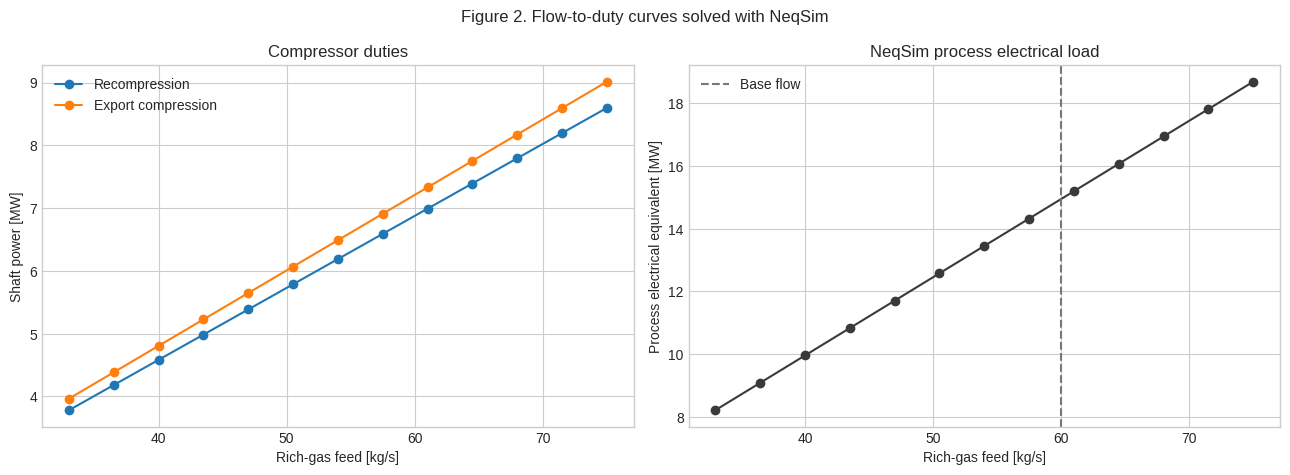

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    process_curve["flow_kg_s"],
    process_curve["recompression_mw"],
    "o-",
    label="Recompression",
)
axes[0].plot(
    process_curve["flow_kg_s"],
    process_curve["export_compression_mw"],
    "o-",
    label="Export compression",
)
axes[0].set(
    xlabel="Rich-gas feed [kg/s]",
    ylabel="Shaft power [MW]",
    title="Compressor duties",
)
axes[0].legend()

axes[1].plot(
    process_curve["flow_kg_s"],
    process_curve["process_electric_mw"],
    "o-",
    color=COLOR_PROCESS,
)
axes[1].axvline(
    BASE_FLOW_KG_S,
    color="#777777",
    linestyle="--",
    label="Base flow",
)
axes[1].set(
    xlabel="Rich-gas feed [kg/s]",
    ylabel="Process electrical equivalent [MW]",
    title="NeqSim process electrical load",
)
axes[1].legend()
fig.suptitle("Figure 2. Flow-to-duty curves solved with NeqSim")
fig.tight_layout()
plt.show()

In [10]:
STUDY_HOURS = 24 * 30
TIME_STEP_H = 1.0
hours = np.arange(STUDY_HOURS, dtype=float)
rng = np.random.default_rng(24052024)

flow_factor = (
    0.98
    + 0.10 * np.sin(2.0 * np.pi * hours / (24.0 * 8.0))
    + 0.04 * np.sin(2.0 * np.pi * hours / 17.0)
)
flow_factor[330:354] *= np.linspace(1.0, 0.65, 24)
flow_factor[354:378] *= np.linspace(0.65, 1.0, 24)
flow_factor = np.clip(flow_factor, 0.58, 1.18)
hourly_flow_kg_s = BASE_FLOW_KG_S * flow_factor

hourly_process_mw = np.interp(
    hourly_flow_kg_s,
    process_curve["flow_kg_s"],
    process_curve["process_electric_mw"],
)
utilities_mw = (
    HOTEL_LOAD_MW
    + FLOW_LINKED_UTILITIES_MW * flow_factor
    + 0.7 * np.sin(2.0 * np.pi * hours / 24.0)
)
total_load_mw = hourly_process_mw + utilities_mw

load_frame = pd.DataFrame(
    {
        "hour": hours,
        "feed_kg_s": hourly_flow_kg_s,
        "neqsim_process_mw": hourly_process_mw,
        "other_utilities_mw": utilities_mw,
        "total_load_mw": total_load_mw,
    }
)
display(load_frame.describe().round(3))

,hour,feed_kg_s,neqsim_process_mw,other_utilities_mw,total_load_mw
count,720.00,720.000,720.000,720.000,720.000
mean,359.50,58.448,14.557,24.483,39.040
std,207.99,5.884,1.466,2.026,3.466
min,0.00,34.800,8.667,15.900,24.567
25%,179.75,54.956,13.687,23.220,36.876
50%,359.50,59.286,14.766,24.797,39.490
75%,539.25,62.740,15.626,26.010,41.647
max,719.00,67.177,16.731,28.020,44.716


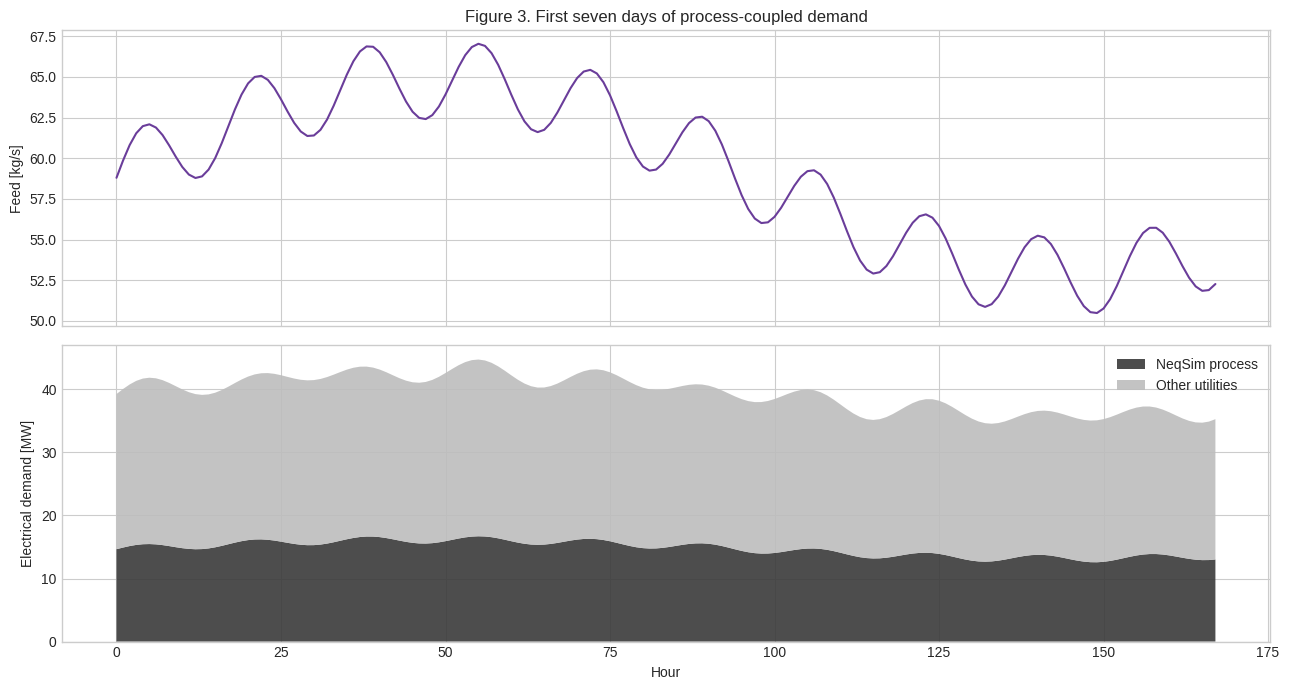

In [11]:
display_hours = slice(0, 24 * 7)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(
    hours[display_hours],
    hourly_flow_kg_s[display_hours],
    color="#6A3D9A",
)
axes[0].set_ylabel("Feed [kg/s]")
axes[0].set_title(
    "Figure 3. First seven days of process-coupled demand"
)

axes[1].stackplot(
    hours[display_hours],
    hourly_process_mw[display_hours],
    utilities_mw[display_hours],
    labels=["NeqSim process", "Other utilities"],
    colors=[COLOR_PROCESS, "#BDBDBD"],
    alpha=0.9,
)
axes[1].set(
    xlabel="Hour",
    ylabel="Electrical demand [MW]",
)
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

## 4. Native gas-turbine fleet at the actual fuel composition

Three 32 MW `LM2500PLUS_G4` units are installed. At most two are required in normal
operation, leaving one unit as N+1 reserve. All scenarios retain the same installed
gas-turbine capacity, even when shore power or wind supplies most annual energy.

For each total gas-generation demand, the smallest number of operating units that
keeps the per-unit target below 85% of available site power is committed. NeqSim
then calculates heat rate, fuel mass, and CO₂ from the separated/export-gas
composition.

$$
\dot E_{fuel}(t) =
P_{GT}(t)\frac{HR(L(t),T_{amb})}{3600}
\qquad
\dot m_{CO_2}(t)=
f_{NeqSim}\left(\dot E_{fuel},\mathbf{x}_{fuel}\right)
$$

In [12]:
INSTALLED_GT_UNITS = 3
FIRM_GT_UNITS = 2
TARGET_MAX_LOAD = 0.85
fuel_stream = base_case["export cooler"].getOutletStream()
turbine_spec = GasTurbineCatalog.get(TURBINE_MODEL)


def run_one_turbine(demand_mw):
    turbine = GasTurbineUnit(
        "hourly gas turbine",
        fuel_stream,
        turbine_spec,
    )
    turbine.setAmbientTemperatureK(AMBIENT_TEMPERATURE_K)
    turbine.setAmbientPressureBara(1.01325)
    turbine.setDemandedPower(float(demand_mw) * 1.0e6)
    turbine.run()
    return {
        "available_mw": turbine.getAvailablePowerW() / 1.0e6,
        "load_fraction": turbine.getLoadFraction(),
        "efficiency": turbine.getThermalEfficiency(),
        "heat_rate_kj_kwh": (
            turbine.getEffectiveHeatRateKJPerKWh()
        ),
        "fuel_kg_h": turbine.getFuelMassFlowKgPerHr(),
        "co2_kg_h": turbine.getCO2EmissionKgPerHr(),
        "co2_kg_mwh": turbine.getCO2IntensityKgPerMWh(),
        "below_minimum": bool(turbine.isBelowMinLoad()),
        "overloaded": bool(turbine.isOverloaded()),
    }


probe_turbine = run_one_turbine(1.0)
unit_available_mw = probe_turbine["available_mw"]
firm_gt_capacity_mw = FIRM_GT_UNITS * unit_available_mw
installed_gt_capacity_mw = INSTALLED_GT_UNITS * unit_available_mw


def native_fleet_point(total_demand_mw):
    if total_demand_mw <= 1.0e-12:
        return {
            "co2_kg_h": 0.0,
            "fuel_kg_h": 0.0,
            "fuel_mwh_th_h": 0.0,
            "efficiency": np.nan,
            "active_units": 0,
            "below_minimum": False,
        }
    target_per_unit = TARGET_MAX_LOAD * unit_available_mw
    active_units = int(
        math.ceil(total_demand_mw / target_per_unit)
    )
    active_units = max(1, min(INSTALLED_GT_UNITS, active_units))
    per_unit_mw = total_demand_mw / active_units
    point = run_one_turbine(per_unit_mw)
    return {
        "co2_kg_h": active_units * point["co2_kg_h"],
        "fuel_kg_h": active_units * point["fuel_kg_h"],
        "fuel_mwh_th_h": (
            total_demand_mw
            * point["heat_rate_kj_kwh"]
            / 3600.0
        ),
        "efficiency": point["efficiency"],
        "active_units": active_units,
        "below_minimum": point["below_minimum"],
    }


gt_grid_mw = np.linspace(0.0, firm_gt_capacity_mw, 257)
gt_map_rows = []
for demand_mw in gt_grid_mw:
    gt_map_rows.append(
        {
            "demand_mw": demand_mw,
            **native_fleet_point(demand_mw),
        }
    )
gt_map = pd.DataFrame(gt_map_rows)

fleet_overview = pd.DataFrame(
    [
        {
            "Model": TURBINE_MODEL,
            "Installed units": INSTALLED_GT_UNITS,
            "Site power per unit [MW]": unit_available_mw,
            "N+1 firm capacity [MW]": firm_gt_capacity_mw,
            "Peak platform load [MW]": total_load_mw.max(),
        }
    ]
)
display(fleet_overview.round(3))

,Model,Installed units,Site power per unit [MW],N+1 firm capacity [MW],Peak platform load [MW]
0,LM2500PLUS_G4,3,33.568,67.136,44.716


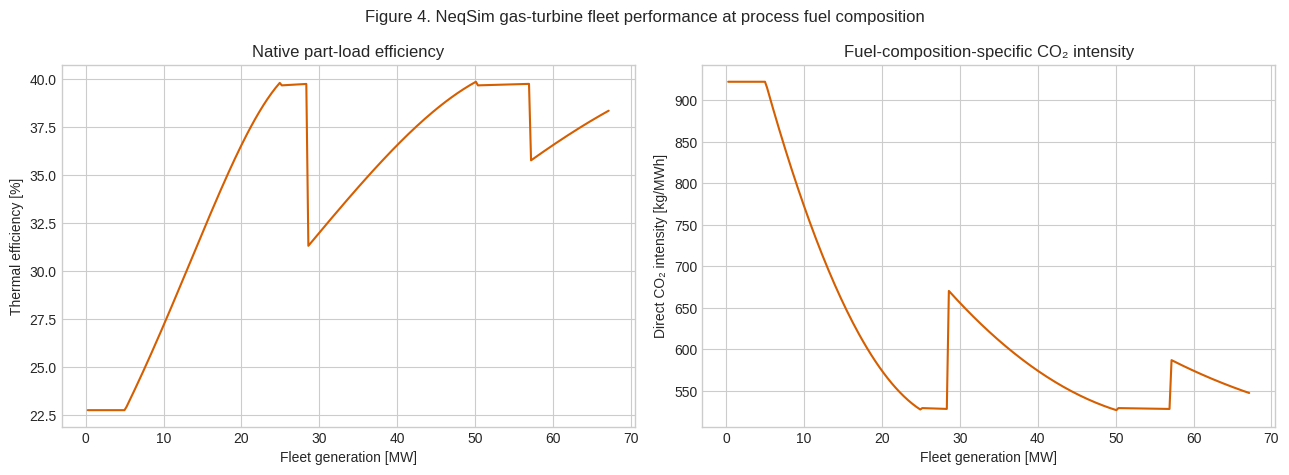

In [13]:
positive_map = gt_map["demand_mw"] > 0.0
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    gt_map.loc[positive_map, "demand_mw"],
    100.0 * gt_map.loc[positive_map, "efficiency"],
    color=COLOR_GAS,
)
axes[0].set(
    xlabel="Fleet generation [MW]",
    ylabel="Thermal efficiency [%]",
    title="Native part-load efficiency",
)
axes[1].plot(
    gt_map.loc[positive_map, "demand_mw"],
    gt_map.loc[positive_map, "co2_kg_h"]
    / gt_map.loc[positive_map, "demand_mw"],
    color=COLOR_GAS,
)
axes[1].set(
    xlabel="Fleet generation [MW]",
    ylabel="Direct CO₂ intensity [kg/MWh]",
    title="Fuel-composition-specific CO₂ intensity",
)
fig.suptitle(
    "Figure 4. NeqSim gas-turbine fleet performance at process fuel composition"
)
fig.tight_layout()
plt.show()

## 5. Chronological wind, shore-power, and battery cases

The 30-day hourly wind series is synthetic and shifted to an illustrative 50%
capacity factor. A 24-hour cable outage is inserted in the shore-power profile so
the retained gas turbines must demonstrate backup duty. The battery starts empty,
charges only from otherwise-curtailed wind, and therefore cannot create energy
from an initial inventory.

The battery state equation is

$$
SOC_{t+1}=SOC_t+
\eta_c P_{charge,t}\Delta t-
\frac{P_{discharge,t}\Delta t}{\eta_d}
$$

with $0\le SOC\le E_{max}$ and charge/discharge power limited to 40 MW.

In [14]:
WIND_CAPACITY_MW = 94.6
WIND_TARGET_CAPACITY_FACTOR = 0.50
PARTIAL_SHORE_MW = 25.0
FULL_SHORE_MW = 60.0
BATTERY_CAPACITY_MWH = 100.0
BATTERY_POWER_MW = 40.0
BATTERY_CHARGE_EFFICIENCY = 0.95
BATTERY_DISCHARGE_EFFICIENCY = 0.95
GRID_FACTOR_KG_PER_MWH = 11.9


def shift_to_mean(values, target_mean, lower=0.0, upper=1.0):
    low_shift = -1.0
    high_shift = 1.0
    for _ in range(80):
        trial_shift = 0.5 * (low_shift + high_shift)
        shifted = np.clip(values + trial_shift, lower, upper)
        if shifted.mean() < target_mean:
            low_shift = trial_shift
        else:
            high_shift = trial_shift
    return np.clip(values + 0.5 * (low_shift + high_shift), lower, upper)


wind_noise = rng.normal(0.0, 1.0, STUDY_HOURS)
wind_state = np.zeros(STUDY_HOURS)
for index in range(1, STUDY_HOURS):
    wind_state[index] = (
        0.94 * wind_state[index - 1]
        + 0.20 * wind_noise[index]
    )
wind_raw = 0.55 + 0.24 * wind_state
wind_raw[410:470] *= np.linspace(1.0, 0.08, 60)
wind_raw[470:506] *= 0.08
wind_raw[506:554] *= np.linspace(0.08, 1.0, 48)
wind_capacity_factor = shift_to_mean(
    wind_raw,
    WIND_TARGET_CAPACITY_FACTOR,
)
wind_available_mw = WIND_CAPACITY_MW * wind_capacity_factor

shore_availability = np.ones(STUDY_HOURS)
shore_availability[432:456] = 0.0
partial_shore_available_mw = (
    PARTIAL_SHORE_MW * shore_availability
)
full_shore_available_mw = FULL_SHORE_MW * shore_availability

chronology_inputs = pd.DataFrame(
    [
        ["Wind capacity factor", wind_capacity_factor.mean(), "-"],
        ["Wind average power", wind_available_mw.mean(), "MW"],
        ["Cable outage duration", 24.0, "h in 30 days"],
        ["Battery round-trip efficiency", 0.95**2, "-"],
    ],
    columns=["Metric", "Value", "Unit"],
)
display(chronology_inputs.round(3))

,Metric,Value,Unit
0,Wind capacity factor,0.500,-
1,Wind average power,47.300,MW
2,Cable outage duration,24.000,h in 30 days
3,Battery round-trip efficiency,0.902,-


In [15]:
times_seconds = JArray(JDouble)((hours * 3600.0).tolist())


def java_double_array(values):
    return JArray(JDouble)(np.asarray(values, dtype=float).tolist())


flow_profile = EnergyTimeSeriesProfile.step(
    "process gas flow",
    times_seconds,
    java_double_array(hourly_flow_kg_s),
)
wind_profile = EnergyTimeSeriesProfile.step(
    "synthetic offshore wind",
    times_seconds,
    java_double_array(wind_available_mw * 1.0e6),
)
load_profile = EnergyTimeSeriesProfile.step(
    "process-coupled electrical demand",
    times_seconds,
    java_double_array(total_load_mw * 1.0e6),
)

profile_sample = pd.DataFrame(
    {
        "Hour": [0, 120, 360, 500],
        "Flow from NeqSim profile [kg/s]": [
            flow_profile.getValue(float(value * 3600.0))
            for value in [0, 120, 360, 500]
        ],
        "Demand profile [MW]": [
            load_profile.getValue(float(value * 3600.0)) / 1.0e6
            for value in [0, 120, 360, 500]
        ],
        "Wind profile [MW]": [
            wind_profile.getValue(float(value * 3600.0)) / 1.0e6
            for value in [0, 120, 360, 500]
        ],
    }
)
display(profile_sample.round(3))

,Hour,Flow from NeqSim profile [kg/s],Demand profile [MW],Wind profile [MW]
0,0,58.800,39.245,54.725
1,120,55.424,37.279,51.530
2,360,42.036,29.482,59.128
3,500,56.411,37.247,8.977


In [16]:
def make_port(owner, direction, mode, bus, priority):
    port = EnergyPort(
        "power",
        EnergyType.ELECTRICAL,
        direction,
        mode,
    )
    port.setOwnerName(owner)
    port.setPriority(priority)
    port.connect(bus)
    return port


def allocation_map(report):
    return {
        str(allocation.getParticipantName()): allocation
        for allocation in report.getAllocations()
    }


def run_native_bus_dispatch(
    name,
    wind_values_mw,
    shore_values_mw,
):
    bus = EnergyBus(f"{name} bus", EnergyType.ELECTRICAL)
    wind = make_port(
        "offshore wind",
        EnergyPortDirection.OUTPUT,
        EnergyPortMode.CALCULATED,
        bus,
        0,
    )
    shore = make_port(
        "shore power",
        EnergyPortDirection.OUTPUT,
        EnergyPortMode.CALCULATED,
        bus,
        5,
    )
    gas = make_port(
        "gas-turbine fleet",
        EnergyPortDirection.OUTPUT,
        EnergyPortMode.CALCULATED,
        bus,
        20,
    )
    demand = make_port(
        "NeqSim process and utilities",
        EnergyPortDirection.INPUT,
        EnergyPortMode.SPECIFICATION,
        bus,
        0,
    )

    simulator = EnergyTimeSeriesSimulator(
        ProcessSystem(f"{name} dispatch")
    )
    simulator.addEnergyBus(bus)
    simulator.setIntervalSeconds(3600.0)
    simulator.setDurationSeconds(STUDY_HOURS * 3600.0)

    profiles = [
        EnergyTimeSeriesProfile.step(
            f"{name} wind",
            times_seconds,
            java_double_array(wind_values_mw * 1.0e6),
        ),
        EnergyTimeSeriesProfile.step(
            f"{name} shore",
            times_seconds,
            java_double_array(shore_values_mw * 1.0e6),
        ),
        EnergyTimeSeriesProfile.step(
            f"{name} gas capacity",
            times_seconds,
            java_double_array(
                np.full(STUDY_HOURS, firm_gt_capacity_mw * 1.0e6)
            ),
        ),
        load_profile,
    ]
    targets = [
        JProxy(
            ProfileTarget,
            dict(apply=lambda value: wind.setDuty(float(value))),
        ),
        JProxy(
            ProfileTarget,
            dict(apply=lambda value: shore.setDuty(float(value))),
        ),
        JProxy(
            ProfileTarget,
            dict(apply=lambda value: gas.setDuty(float(value))),
        ),
        JProxy(
            ProfileTarget,
            dict(
                apply=lambda value: demand.setRequestedPower(
                    float(value)
                )
            ),
        ),
    ]
    for profile, target in zip(profiles, targets):
        simulator.addProfile(profile, target)

    result = simulator.run()
    rows = []
    for interval in result.getIntervals():
        report = interval.getNetworkReports().get(0)
        allocations = allocation_map(report)
        rows.append(
            {
                "hour": interval.getStartTimeSeconds() / 3600.0,
                "demand_mw": report.getServedDemand() / 1.0e6,
                "wind_mw": (
                    allocations["offshore wind.power"]
                    .getAllocatedPower()
                    / 1.0e6
                ),
                "wind_curtailed_mw": (
                    allocations["offshore wind.power"]
                    .getCurtailedPower()
                    / 1.0e6
                ),
                "shore_mw": (
                    allocations["shore power.power"]
                    .getAllocatedPower()
                    / 1.0e6
                ),
                "gas_mw": (
                    allocations["gas-turbine fleet.power"]
                    .getAllocatedPower()
                    / 1.0e6
                ),
                "battery_charge_mw": 0.0,
                "battery_discharge_mw": 0.0,
                "soc_mwh": 0.0,
                "unmet_mw": report.getUnmetDemand() / 1.0e6,
            }
        )
    return pd.DataFrame(rows), targets

In [17]:
def run_battery_dispatch(name, shore_values_mw):
    battery = BatteryStorage(
        f"{name} battery",
        BATTERY_CAPACITY_MWH * 1.0e6,
    )
    battery.setStateOfCharge(0.0)
    battery.setEfficiencies(
        BATTERY_CHARGE_EFFICIENCY,
        BATTERY_DISCHARGE_EFFICIENCY,
    )
    battery.setPowerLimits(
        BATTERY_POWER_MW * 1.0e6,
        BATTERY_POWER_MW * 1.0e6,
    )

    rows = []
    for index in range(STUDY_HOURS):
        demand_mw = total_load_mw[index]
        wind_mw = wind_available_mw[index]
        shore_capacity_mw = shore_values_mw[index]

        wind_to_load_mw = min(wind_mw, demand_mw)
        remaining_mw = demand_mw - wind_to_load_mw
        wind_surplus_mw = wind_mw - wind_to_load_mw

        if wind_surplus_mw > 0.0:
            headroom_mwh = (
                battery.getCapacity()
                - battery.getStateOfCharge()
            ) / 1.0e6
            headroom_power_mw = (
                headroom_mwh
                / BATTERY_CHARGE_EFFICIENCY
                / TIME_STEP_H
            )
            charge_mw = min(
                wind_surplus_mw,
                BATTERY_POWER_MW,
                headroom_power_mw,
            )
            battery.charge(charge_mw * 1.0e6, TIME_STEP_H)
            discharge_mw = 0.0
        else:
            requested_discharge_mw = min(
                remaining_mw,
                BATTERY_POWER_MW,
            )
            discharge_w = battery.discharge(
                requested_discharge_mw * 1.0e6,
                TIME_STEP_H,
            )
            discharge_mw = discharge_w / 1.0e6
            charge_mw = 0.0
            remaining_mw -= discharge_mw

        shore_mw = min(remaining_mw, shore_capacity_mw)
        gas_mw = max(0.0, remaining_mw - shore_mw)
        wind_curtailed_mw = max(
            0.0,
            wind_surplus_mw - charge_mw,
        )
        rows.append(
            {
                "hour": float(index),
                "demand_mw": demand_mw,
                "wind_mw": wind_to_load_mw,
                "wind_curtailed_mw": wind_curtailed_mw,
                "shore_mw": shore_mw,
                "gas_mw": gas_mw,
                "battery_charge_mw": charge_mw,
                "battery_discharge_mw": discharge_mw,
                "soc_mwh": (
                    battery.getStateOfCharge() / 1.0e6
                ),
                "unmet_mw": 0.0,
            }
        )
    return pd.DataFrame(rows)


zero_profile = np.zeros(STUDY_HOURS)
dispatches = {}
retained_targets = []
no_battery_cases = [
    ("Gas turbines only", zero_profile, zero_profile),
    ("25 MW shore + GT", zero_profile, partial_shore_available_mw),
    ("60 MW shore + GT", zero_profile, full_shore_available_mw),
    ("Wind + GT", wind_available_mw, zero_profile),
]
for name, wind_values, shore_values in no_battery_cases:
    dispatch, targets = run_native_bus_dispatch(
        name,
        wind_values,
        shore_values,
    )
    dispatches[name] = dispatch
    retained_targets.extend(targets)

dispatches["Wind + 100 MWh battery + GT"] = (
    run_battery_dispatch(
        "wind battery",
        zero_profile,
    )
)
dispatches["25 MW shore + wind + battery + GT"] = (
    run_battery_dispatch(
        "hybrid",
        partial_shore_available_mw,
    )
)

## 6. Convert hourly gas duty to native fuel use and emissions

The time-series energy bus determines accepted gas generation. NeqSim's
part-load map then supplies fuel and CO₂ at every hourly gas duty. Linear
interpolation is applied to a dense native turbine map, not to a fixed emission
factor.

Direct offshore emissions include only gas-turbine combustion:

$$
M_{CO_2,direct}=\sum_t \dot m_{CO_2,GT}(P_{GT,t})\Delta t
$$

The location-based screening total adds imported electricity:

$$
M_{CO_2,location}=M_{CO_2,direct}
+ E_{shore}\,EF_{grid}
$$

Wind and battery operation are assigned zero direct emissions here. Lifecycle,
construction, export displacement, and market effects are outside the boundary.

In [18]:
ANNUALISATION_FACTOR = 8760.0 / STUDY_HOURS
GAS_VALUE_NOK_PER_MWH_TH = 350.0
SHORE_POWER_NOK_PER_MWH = 600.0
CO2_COST_NOK_PER_TONNE = 1860.0


def add_native_turbine_results(dispatch):
    gas_values = dispatch["gas_mw"].to_numpy()
    dispatch = dispatch.copy()
    dispatch["gt_co2_kg_h"] = np.interp(
        gas_values,
        gt_map["demand_mw"],
        gt_map["co2_kg_h"],
    )
    dispatch["gt_fuel_kg_h"] = np.interp(
        gas_values,
        gt_map["demand_mw"],
        gt_map["fuel_kg_h"],
    )
    dispatch["gt_fuel_mwh_th_h"] = np.interp(
        gas_values,
        gt_map["demand_mw"],
        gt_map["fuel_mwh_th_h"],
    )
    return dispatch


for scenario_name, dispatch in list(dispatches.items()):
    dispatches[scenario_name] = add_native_turbine_results(
        dispatch
    )


def scenario_metrics(name, dispatch):
    annual_load_mwh = (
        dispatch["demand_mw"].sum()
        * TIME_STEP_H
        * ANNUALISATION_FACTOR
    )
    annual_gas_mwh = (
        dispatch["gas_mw"].sum()
        * TIME_STEP_H
        * ANNUALISATION_FACTOR
    )
    annual_shore_mwh = (
        dispatch["shore_mw"].sum()
        * TIME_STEP_H
        * ANNUALISATION_FACTOR
    )
    annual_wind_mwh = (
        dispatch["wind_mw"].sum()
        * TIME_STEP_H
        * ANNUALISATION_FACTOR
    )
    annual_direct_co2_t = (
        dispatch["gt_co2_kg_h"].sum()
        * TIME_STEP_H
        * ANNUALISATION_FACTOR
        / 1000.0
    )
    grid_co2_t = (
        annual_shore_mwh
        * GRID_FACTOR_KG_PER_MWH
        / 1000.0
    )
    annual_fuel_mwh_th = (
        dispatch["gt_fuel_mwh_th_h"].sum()
        * TIME_STEP_H
        * ANNUALISATION_FACTOR
    )
    operating_proxy_mnok = (
        annual_fuel_mwh_th * GAS_VALUE_NOK_PER_MWH_TH
        + annual_shore_mwh * SHORE_POWER_NOK_PER_MWH
        + annual_direct_co2_t * CO2_COST_NOK_PER_TONNE
    ) / 1.0e6
    return {
        "Scenario": name,
        "Load [GWh/y]": annual_load_mwh / 1000.0,
        "GT [GWh/y]": annual_gas_mwh / 1000.0,
        "Shore [GWh/y]": annual_shore_mwh / 1000.0,
        "Wind [GWh/y]": annual_wind_mwh / 1000.0,
        "Wind curtailed [GWh/y]": (
            dispatch["wind_curtailed_mw"].sum()
            * TIME_STEP_H
            * ANNUALISATION_FACTOR
            / 1000.0
        ),
        "Direct CO₂ [kt/y]": annual_direct_co2_t / 1000.0,
        "Location CO₂e [kt/y]": (
            annual_direct_co2_t + grid_co2_t
        )
        / 1000.0,
        "Peak GT [MW]": dispatch["gas_mw"].max(),
        "GT operating hours [h/y]": (
            (dispatch["gas_mw"] > 0.05).sum()
            * ANNUALISATION_FACTOR
        ),
        "Operating proxy [MNOK/y]": operating_proxy_mnok,
    }


annual_results = pd.DataFrame(
    [
        scenario_metrics(name, dispatch)
        for name, dispatch in dispatches.items()
    ]
).set_index("Scenario")
baseline_co2 = annual_results.loc[
    "Gas turbines only",
    "Direct CO₂ [kt/y]",
]
annual_results["Direct CO₂ reduction [%]"] = 100.0 * (
    1.0 - annual_results["Direct CO₂ [kt/y]"] / baseline_co2
)
display(annual_results.round(2))

,Load [GWh/y],GT [GWh/y],Shore [GWh/y],Wind [GWh/y],Wind curtailed [GWh/y],Direct CO₂ [kt/y],Location CO₂e [kt/y],Peak GT [MW],GT operating hours [h/y],Operating proxy [MNOK/y],Direct CO₂ reduction [%]
Scenario,,,,,,,,,,,
Gas turbines only,341.99,341.99,0.00,0.0,0.00,197.86,197.86,44.72,8760.00,698.04,0.00
25 MW shore + GT,341.99,130.31,211.68,0.0,0.00,85.44,87.96,43.50,8699.17,428.42,56.82
60 MW shore + GT,341.99,12.34,329.65,0.0,0.00,6.92,10.84,43.50,292.00,222.19,96.50
Wind + GT,341.99,33.09,0.00,308.9,105.45,21.12,21.12,34.22,1971.00,74.51,89.33
Wind + 100 MWh battery + GT,341.99,29.37,-0.00,308.9,100.05,18.18,18.18,34.22,1301.83,64.15,90.81
25 MW shore + wind + battery + GT,341.99,8.31,21.06,308.9,100.05,5.69,5.94,25.48,863.83,32.71,97.12


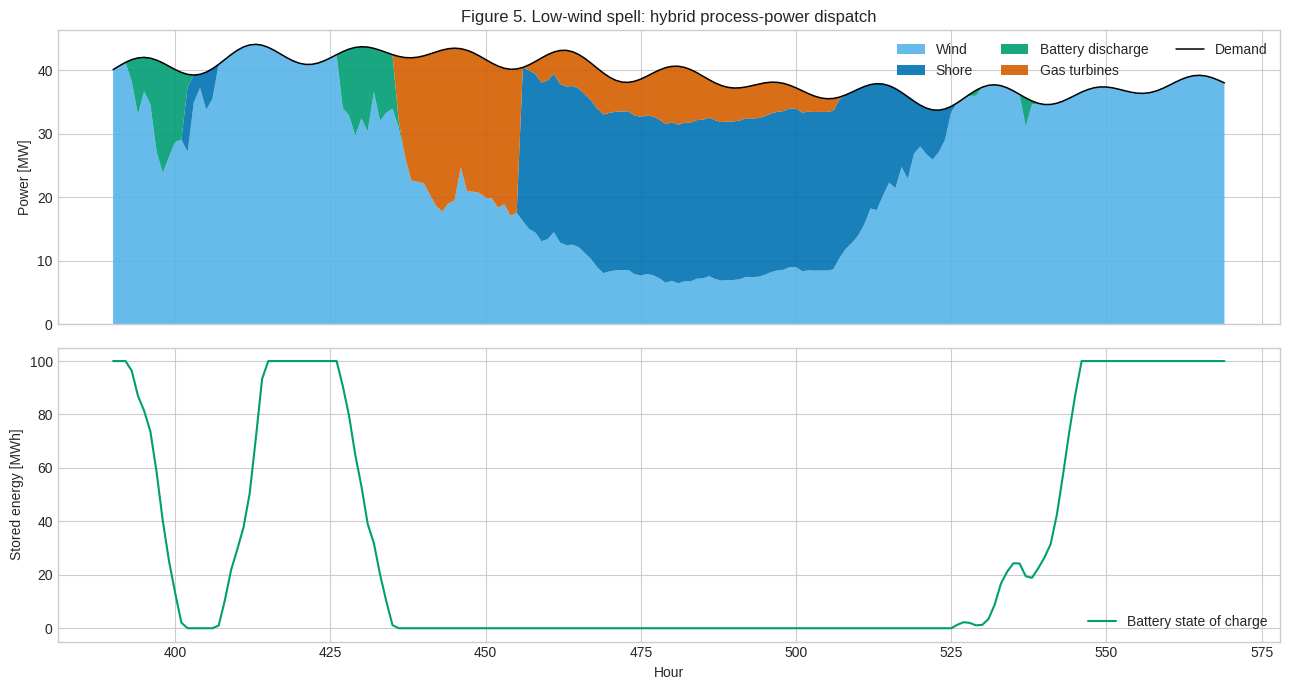

In [19]:
scenario_to_plot = "25 MW shore + wind + battery + GT"
plot_start_hour = 390
plot_end_hour = 570
plotted_dispatch = dispatches[scenario_to_plot].iloc[
    plot_start_hour:plot_end_hour
]
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].stackplot(
    plotted_dispatch["hour"],
    plotted_dispatch["wind_mw"],
    plotted_dispatch["shore_mw"],
    plotted_dispatch["battery_discharge_mw"],
    plotted_dispatch["gas_mw"],
    labels=["Wind", "Shore", "Battery discharge", "Gas turbines"],
    colors=[
        COLOR_WIND,
        COLOR_SHORE,
        COLOR_BATTERY,
        COLOR_GAS,
    ],
    alpha=0.9,
)
axes[0].plot(
    plotted_dispatch["hour"],
    plotted_dispatch["demand_mw"],
    color="black",
    linewidth=1.1,
    label="Demand",
)
axes[0].set_ylabel("Power [MW]")
axes[0].set_title(
    "Figure 5. Low-wind spell: hybrid process-power dispatch"
)
axes[0].legend(ncol=3, loc="upper right")

axes[1].plot(
    plotted_dispatch["hour"],
    plotted_dispatch["soc_mwh"],
    color=COLOR_BATTERY,
    label="Battery state of charge",
)
axes[1].set(
    xlabel="Hour",
    ylabel="Stored energy [MWh]",
)
axes[1].legend()
fig.tight_layout()
plt.show()

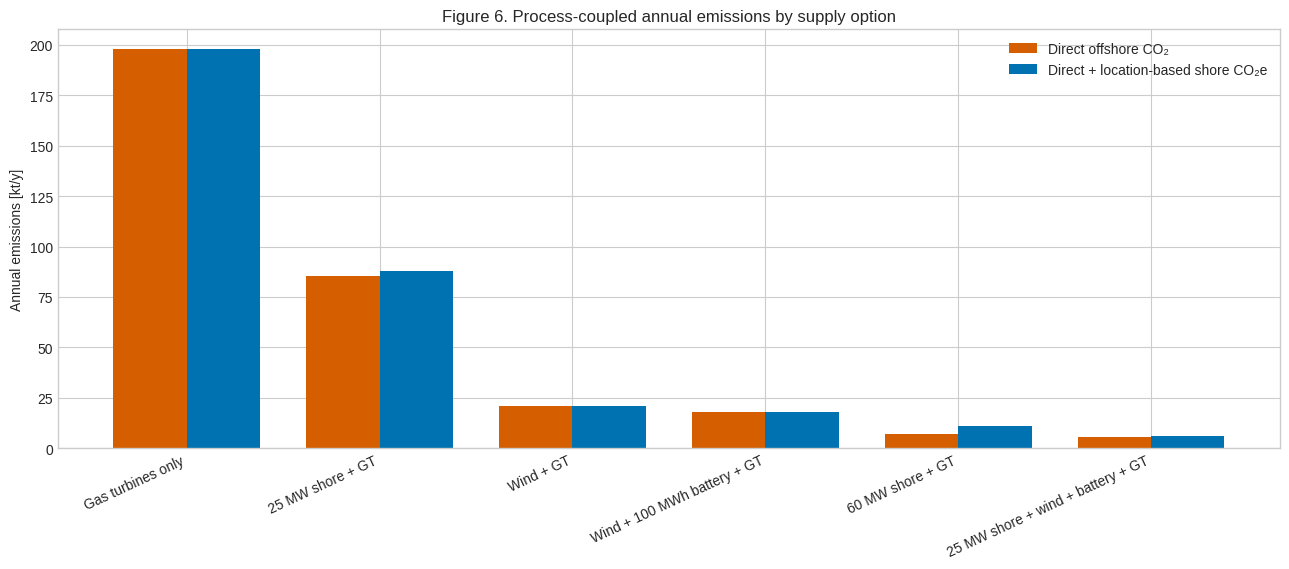

In [20]:
figure_results = annual_results.sort_values(
    "Direct CO₂ [kt/y]",
    ascending=False,
)
positions = np.arange(len(figure_results))
width = 0.38
fig, ax = plt.subplots(figsize=(13, 5.8))
ax.bar(
    positions - width / 2.0,
    figure_results["Direct CO₂ [kt/y]"],
    width,
    color=COLOR_GAS,
    label="Direct offshore CO₂",
)
ax.bar(
    positions + width / 2.0,
    figure_results["Location CO₂e [kt/y]"],
    width,
    color=COLOR_SHORE,
    label="Direct + location-based shore CO₂e",
)
ax.set_xticks(positions)
ax.set_xticklabels(
    figure_results.index,
    rotation=25,
    ha="right",
)
ax.set_ylabel("Annual emissions [kt/y]")
ax.set_title(
    "Figure 6. Process-coupled annual emissions by supply option"
)
ax.legend()
fig.tight_layout()
plt.show()

## 7. Economics and field-maturity sensitivity

The operating-cost proxy values gas at 350 NOK/MWh thermal, shore electricity at
600 NOK/MWh, and direct CO₂ at 1,860 NOK/t. They are editable screening inputs.
Wind, cable, battery, maintenance, availability, taxes, and all capital expenditure
are excluded. The proxy therefore cannot rank investments; it only shows the
operating-value space available to pay annualised capital and fixed costs.

$$
C_{proxy}=E_{fuel}c_{gas}+E_{shore}c_{power}
+M_{CO_2,direct}c_{CO_2}
$$

A field-maturity test scales the hourly NeqSim-linked load while retaining hotel
load. This exposes a common late-life issue: lower average demand may increase wind
curtailment and turbine part-load operation without reducing the firm-capacity
requirement in proportion.

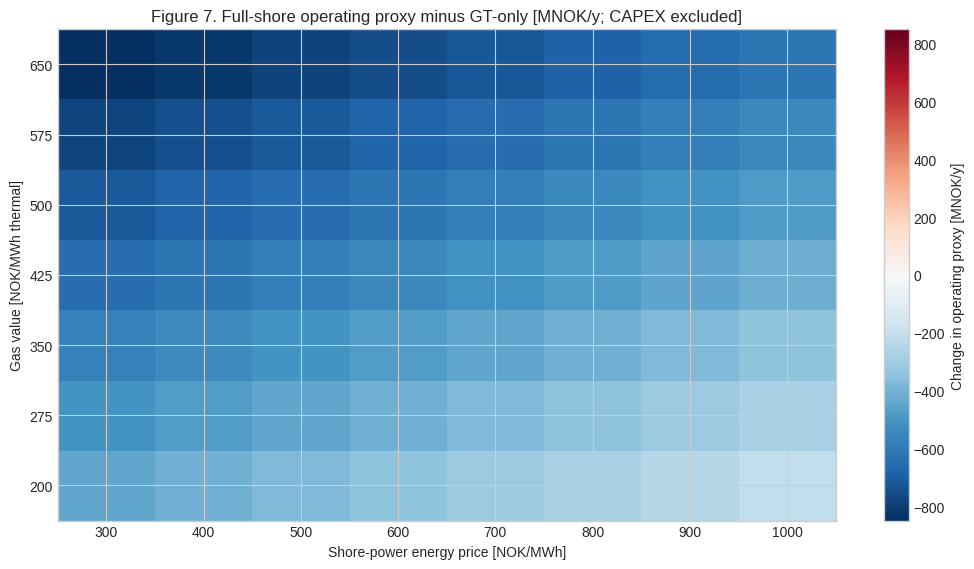

In [21]:
shore_prices = np.arange(300.0, 1001.0, 100.0)
gas_values = np.arange(200.0, 651.0, 75.0)
full_shore_row = dispatches["60 MW shore + GT"]
baseline_row = dispatches["Gas turbines only"]


def operating_proxy(dispatch, gas_value, shore_price):
    annual_fuel = (
        dispatch["gt_fuel_mwh_th_h"].sum()
        * ANNUALISATION_FACTOR
    )
    annual_shore = (
        dispatch["shore_mw"].sum() * ANNUALISATION_FACTOR
    )
    annual_co2_t = (
        dispatch["gt_co2_kg_h"].sum()
        * ANNUALISATION_FACTOR
        / 1000.0
    )
    return (
        annual_fuel * gas_value
        + annual_shore * shore_price
        + annual_co2_t * CO2_COST_NOK_PER_TONNE
    ) / 1.0e6


cost_delta = np.zeros((len(gas_values), len(shore_prices)))
for row_index, gas_value in enumerate(gas_values):
    for column_index, shore_price in enumerate(shore_prices):
        cost_delta[row_index, column_index] = (
            operating_proxy(
                full_shore_row,
                gas_value,
                shore_price,
            )
            - operating_proxy(
                baseline_row,
                gas_value,
                shore_price,
            )
        )

fig, ax = plt.subplots(figsize=(10.5, 5.8))
maximum = np.max(np.abs(cost_delta))
image = ax.imshow(
    cost_delta,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-maximum,
    vmax=maximum,
)
ax.set_xticks(np.arange(len(shore_prices)))
ax.set_xticklabels(shore_prices.astype(int))
ax.set_yticks(np.arange(len(gas_values)))
ax.set_yticklabels(gas_values.astype(int))
ax.set(
    xlabel="Shore-power energy price [NOK/MWh]",
    ylabel="Gas value [NOK/MWh thermal]",
    title=(
        "Figure 7. Full-shore operating proxy minus GT-only "
        "[MNOK/y; CAPEX excluded]"
    ),
)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Change in operating proxy [MNOK/y]")
fig.tight_layout()
plt.show()

,Production scaling,Mean flow [kg/s],Mean load [MW],Wind share [%],GT energy [GWh/y],Wind curtailment [GWh/y],Peak load [MW]
0,0.60,48.27,33.11,92.21,22.58,146.87,36.16
1,0.75,52.09,35.33,91.55,26.16,130.98,39.15
2,1.00,58.45,39.04,90.30,33.17,105.53,44.12
3,1.15,62.26,41.26,89.45,38.15,91.04,47.11


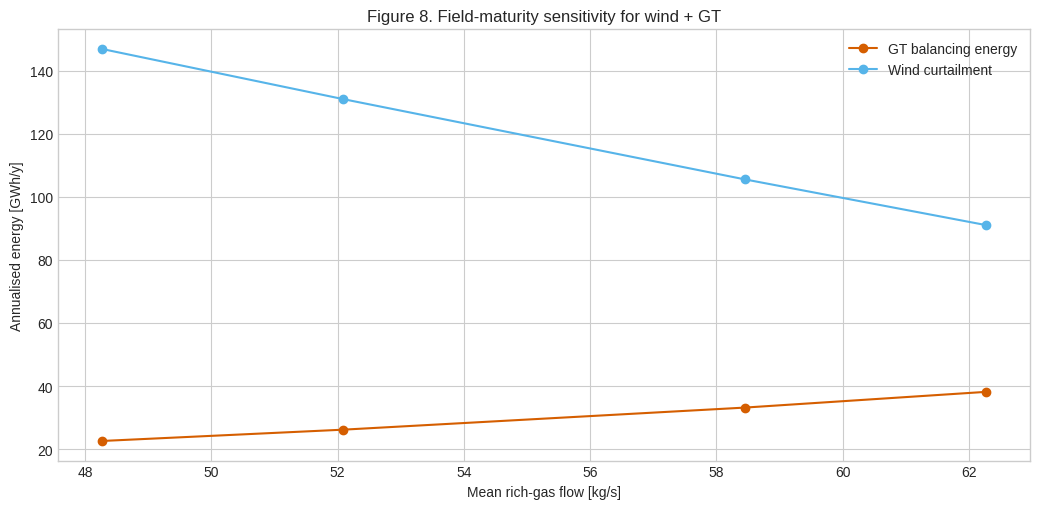

In [22]:
maturity_factors = np.array([0.60, 0.75, 1.00, 1.15])
maturity_rows = []
for maturity in maturity_factors:
    scaled_flow = BASE_FLOW_KG_S * (
        0.55 + maturity * (flow_factor - 0.55)
    )
    scaled_process = np.interp(
        scaled_flow,
        process_curve["flow_kg_s"],
        process_curve["process_electric_mw"],
    )
    scaled_utilities = (
        HOTEL_LOAD_MW
        + FLOW_LINKED_UTILITIES_MW
        * scaled_flow
        / BASE_FLOW_KG_S
    )
    scaled_load = scaled_process + scaled_utilities
    wind_to_load = np.minimum(wind_available_mw, scaled_load)
    gas_without_battery = scaled_load - wind_to_load
    maturity_rows.append(
        {
            "Production scaling": maturity,
            "Mean flow [kg/s]": scaled_flow.mean(),
            "Mean load [MW]": scaled_load.mean(),
            "Wind share [%]": (
                100.0
                * wind_to_load.sum()
                / scaled_load.sum()
            ),
            "GT energy [GWh/y]": (
                gas_without_battery.sum()
                * ANNUALISATION_FACTOR
                / 1000.0
            ),
            "Wind curtailment [GWh/y]": (
                (wind_available_mw - wind_to_load).sum()
                * ANNUALISATION_FACTOR
                / 1000.0
            ),
            "Peak load [MW]": scaled_load.max(),
        }
    )

maturity_results = pd.DataFrame(maturity_rows)
display(maturity_results.round(2))

fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.plot(
    maturity_results["Mean flow [kg/s]"],
    maturity_results["GT energy [GWh/y]"],
    "o-",
    color=COLOR_GAS,
    label="GT balancing energy",
)
ax.plot(
    maturity_results["Mean flow [kg/s]"],
    maturity_results["Wind curtailment [GWh/y]"],
    "o-",
    color=COLOR_WIND,
    label="Wind curtailment",
)
ax.set(
    xlabel="Mean rich-gas flow [kg/s]",
    ylabel="Annualised energy [GWh/y]",
    title="Figure 8. Field-maturity sensitivity for wind + GT",
)
ax.legend()
fig.tight_layout()
plt.show()

## 8. Validation gates

These checks fail loudly if the thermodynamic process, direct compressor/turbine
coupling, interpolation, hourly energy balances, battery inventory, or firm
capacity are inconsistent. The interpolation check deliberately runs four new
NeqSim process cases that were not used to build the duty curve.

In [23]:
checks = {}

print(
    "Shaft-bus diagnostic: "
    f"unmet={base_result['Bus unmet [W]']:.6f} W, "
    f"turbine demand={base_result['GT direct demand [MW]']:.6f} MW"
)
checks["composition sums to one"] = abs(
    sum(COMPONENTS.values()) - 1.0
) < 1.0e-12
checks["base mass balance closes"] = abs(
    base_result["Mass residual [kg/h]"]
) < 1.0e-4
checks["recompression power positive"] = (
    base_result["Recompression [MW]"] > 0.0
)
checks["export compressor power positive"] = (
    base_result["Export compression [MW]"] > 0.0
)
checks["export compressor has material duty"] = (
    base_result["Export compression [MW]"] > 2.0
)
checks["export pressure reached"] = abs(
    base_result["Export pressure [bara]"] - EXPORT_PRESSURE_BARA
) < 0.02
checks["export cooler target reached"] = abs(
    base_result["Export temperature [°C]"]
    - AFTERCOOLER_TEMPERATURE_C
) < 0.05
checks["direct turbine reads both compressors"] = abs(
    base_result["GT direct demand [MW]"]
    - base_result["Recompression [MW]"]
    - base_result["Export compression [MW]"]
) < 1.0e-6
shaft_bus_relative_residual = abs(
    base_result["Bus unmet [W]"]
) / (base_result["GT direct demand [MW]"] * 1.0e6)
checks["shaft-work EnergyBus relative residual below 1e-9"] = (
    shaft_bus_relative_residual < 1.0e-9
)
checks["direct turbine CO2 positive"] = (
    base_result["GT direct CO₂ [kg/h]"] > 0.0
)
checks["process power increases with flow"] = np.all(
    np.diff(process_curve["process_electric_mw"]) > 0.0
)

interpolation_errors = []
for check_flow in [37.2, 48.6, 63.3, 71.4]:
    direct_case = build_process_case(
        check_flow,
        connect_turbine=False,
    )
    direct_result = process_results(direct_case)
    direct_power = electrical_process_power(direct_result)
    interpolated_power = np.interp(
        check_flow,
        process_curve["flow_kg_s"],
        process_curve["process_electric_mw"],
    )
    interpolation_errors.append(
        abs(interpolated_power - direct_power) / direct_power
    )
checks["process interpolation error below 0.5%"] = (
    max(interpolation_errors) < 0.005
)
checks["all hourly flows inside solved envelope"] = (
    hourly_flow_kg_s.min() >= flow_grid_kg_s.min()
    and hourly_flow_kg_s.max() <= flow_grid_kg_s.max()
)
checks["demand decomposition closes"] = np.allclose(
    total_load_mw,
    hourly_process_mw + utilities_mw,
    atol=1.0e-10,
)
checks["wind capacity factor target reached"] = abs(
    wind_capacity_factor.mean() - WIND_TARGET_CAPACITY_FACTOR
) < 1.0e-8
checks["N+1 gas capacity covers peak load"] = (
    firm_gt_capacity_mw > total_load_mw.max()
)
checks["native turbine map finite"] = np.isfinite(
    gt_map.loc[positive_map, "co2_kg_h"]
).all()
checks["native turbine CO2 positive"] = (
    gt_map.loc[positive_map, "co2_kg_h"] > 0.0
).all()

for name, dispatch in dispatches.items():
    supplied_mw = (
        dispatch["wind_mw"]
        + dispatch["shore_mw"]
        + dispatch["battery_discharge_mw"]
        + dispatch["gas_mw"]
    )
    checks[f"{name}: hourly energy balance"] = np.allclose(
        supplied_mw,
        dispatch["demand_mw"],
        atol=1.0e-7,
    )
    checks[f"{name}: no unmet demand"] = (
        dispatch["unmet_mw"].max() < 1.0e-8
    )
    checks[f"{name}: GT within firm capacity"] = (
        dispatch["gas_mw"].max() <= firm_gt_capacity_mw + 1.0e-8
    )

for name in [
    "Wind + 100 MWh battery + GT",
    "25 MW shore + wind + battery + GT",
]:
    dispatch = dispatches[name]
    checks[f"{name}: battery lower bound"] = (
        dispatch["soc_mwh"].min() >= -1.0e-9
    )
    checks[f"{name}: battery upper bound"] = (
        dispatch["soc_mwh"].max()
        <= BATTERY_CAPACITY_MWH + 1.0e-9
    )
    checks[f"{name}: charge limit"] = (
        dispatch["battery_charge_mw"].max()
        <= BATTERY_POWER_MW + 1.0e-9
    )
    checks[f"{name}: discharge limit"] = (
        dispatch["battery_discharge_mw"].max()
        <= BATTERY_POWER_MW + 1.0e-9
    )

checks["full shore cuts direct CO2"] = (
    annual_results.loc["60 MW shore + GT", "Direct CO₂ [kt/y]"]
    < baseline_co2
)
checks["wind cuts direct CO2"] = (
    annual_results.loc["Wind + GT", "Direct CO₂ [kt/y]"]
    < baseline_co2
)
checks["battery does not increase GT energy"] = (
    annual_results.loc[
        "Wind + 100 MWh battery + GT",
        "GT [GWh/y]",
    ]
    <= annual_results.loc["Wind + GT", "GT [GWh/y]"] + 1.0e-9
)
checks["annual results finite"] = np.isfinite(
    annual_results.select_dtypes(include=[np.number])
).all().all()

validation_table = pd.DataFrame(
    [
        {
            "Check": name,
            "Passed": bool(passed),
        }
        for name, passed in checks.items()
    ]
)
display(validation_table)
failed_checks = validation_table.loc[
    ~validation_table["Passed"],
    "Check",
].tolist()
print(f"Failed validation gates: {failed_checks}")
assert not failed_checks
print(
    f"All {len(validation_table)} validation gates passed. "
    f"Maximum process interpolation error: "
    f"{100.0 * max(interpolation_errors):.4f}%"
)

Shaft-bus diagnostic: unmet=0.006200 W, turbine demand=14.085163 MW


,Check,Passed
0,composition sums to one,True
1,base mass balance closes,True
2,recompression power positive,True
3,export compressor power positive,True
4,export compressor has material duty,True
5,export pressure reached,True
6,export cooler target reached,True
7,direct turbine reads both compressors,True
8,shaft-work EnergyBus relative residual below 1e-9,True
9,direct turbine CO2 positive,True


Failed validation gates: []
All 48 validation gates passed. Maximum process interpolation error: 0.0000%


## 9. Engineering interpretation

Read the executed result table before drawing conclusions. The expected patterns
are:

- The new export compressor is a material process load. Raising export pressure or
  gas flow immediately changes the power and emissions through the NeqSim model.
- Shore power gives a controllable reduction in offshore turbine running, but the
  synthetic cable outage demonstrates why retained generation capacity still
  matters.
- Wind can remove substantial gas-turbine energy, while low-wind periods keep peak
  gas demand and firm-capacity requirements much closer to the baseline than the
  annual-energy reduction might suggest.
- The battery can shift otherwise-curtailed wind into deficit hours. Its CO₂ value
  depends on chronology, power, energy capacity, efficiency, and starting/ending
  inventory—not just installed MWh.
- A hybrid option can reduce both imported energy and turbine fuel, but investment
  ranking requires cable, wind, battery, modifications, availability, maintenance,
  and decommissioning costs beyond this operating proxy.

For concept selection, inspect at least direct CO₂, location-based CO₂e, peak gas
duty, turbine operating hours, wind curtailment, N+1 capacity, and sensitivity to
field decline. No single annual percentage is sufficient.

## Limitations

- The process is a real thermodynamic calculation but a simplified train. It omits
  water injection, produced-water treatment, oil export, flare, fuel conditioning,
  heat integration, pressure losses, rotating-equipment maps, recycle control,
  start-up, and degradation.
- Flow, export pressure, utility loads, wind chronology, cable outage, and economic
  inputs are illustrative. Replace them with asset-specific data.
- Linear interpolation is restricted to the solved flow envelope and checked at
  independent points. Extrapolation is deliberately avoided.
- The hourly dispatch is an energy balance, not a frequency, voltage, fault,
  black-start, transient, protection, or dynamic-stability study.
- Gas-turbine unit commitment is a screening rule. Minimum up/down time, spinning
  reserve, starts, maintenance, and emissions during transitions are excluded.
- Grid CO₂e is a location-based physical-use factor. Consequential, contractual,
  marginal, lifecycle, and cross-border accounting can give different answers.
- Wind and battery lifecycle emissions are excluded.
- Annualisation repeats one deterministic 30-day period and therefore does not
  represent interannual wind or production variability.

## Suggested extensions

1. Sweep export pressure from 120 to 220 bara and plot abatement against process
   energy intensity.
2. Replace the synthetic flow and wind arrays with approved operating data.
3. Add compressor maps, anti-surge recycle, and multiple trains with availability.
4. Add cable losses, voltage constraints, spinning reserve, and dynamic studies.
5. Optimise shore, wind, battery, and retained turbine capacities across field life.

## References

- [Source NeqSim process comparison notebook](../process/comparesimulations.ipynb)
- [NeqSim energy time-series documentation](https://equinor.github.io/neqsim/process/energy_time_series.html)
- [NeqSim energy-stream documentation](https://equinor.github.io/neqsim/process/energy_streams.html)
- [Hywind Tampen](https://www.equinor.com/energy/hywind-tampen)
- [Norwegian Offshore Directorate: The shelf in 2025](https://www.sodir.no/en/whats-new/publications/reports/the-shelf/the-shelf-in-2025/production-operating-fields-and-investments/)
- [NVE: greenhouse-gas emissions associated with Norwegian electricity use](https://www.nve.no/nytt-fra-nve/nyheter-energi/klimagassutslipp-knyttet-til-norsk-stroemforbruk-gaar-ned/)